In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
data=pd.read_csv("Bank Customer Churn Prediction.csv")

In [7]:
import os 
os.getcwd()

'C:\\Users\\HANISHA C'

In [17]:
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [19]:
df=data.head(1000)

In [21]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,15810218,610,Spain,Male,29,9,0.00,3,0,1,83912.24,0
996,15645621,811,Spain,Male,44,3,0.00,2,0,1,78439.73,0
997,15608114,587,Spain,Male,62,7,121286.27,1,0,1,6776.92,0
998,15659557,811,Germany,Female,28,4,167738.82,2,1,1,9903.42,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1000 non-null   int64  
 1   credit_score      1000 non-null   int64  
 2   country           1000 non-null   object 
 3   gender            1000 non-null   object 
 4   age               1000 non-null   int64  
 5   tenure            1000 non-null   int64  
 6   balance           1000 non-null   float64
 7   products_number   1000 non-null   int64  
 8   credit_card       1000 non-null   int64  
 9   active_member     1000 non-null   int64  
 10  estimated_salary  1000 non-null   float64
 11  churn             1000 non-null   int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 93.9+ KB


In [25]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


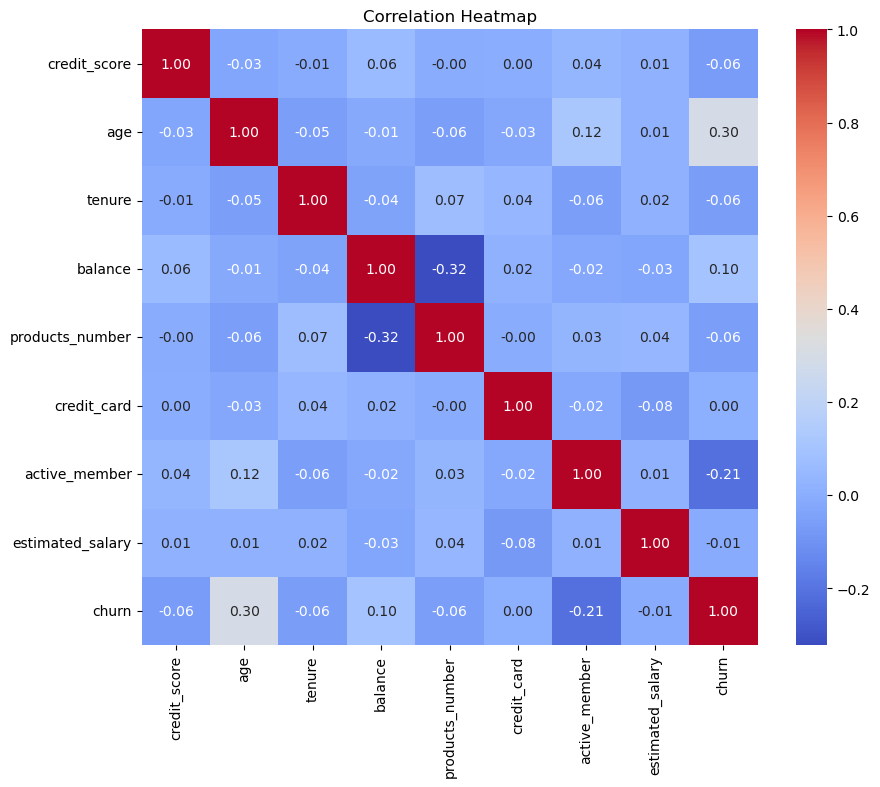

In [29]:
numeric_df=df.drop(columns=['country','gender','customer_id'])
correlation_matrix = numeric_df.corr()


# Set the size of the heatmap
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Add a title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

1. Credit Score and Churn: Negatively correlated, -0.5 
2. Age and Churn: It is positively correlated, around 0.3
3. Tenure and Churn:Negatively correlated, -0.6
4. Balance and Products Number: Positively correlated, 0.7
5. Estimated Salary and Balance:Positively correlated, 0.5
6. Credit score and Tenure are negatively correlated
7. Age, Balance,Estimated salary are positively correlated

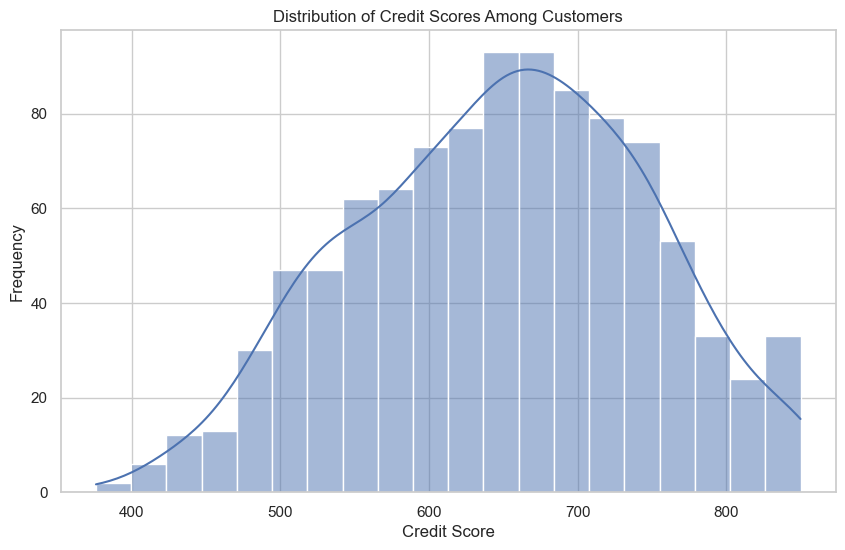

In [31]:
sns.set(style="whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['credit_score'], bins=20, kde=True)  # kde=True adds a Kernel Density Estimate

# Add titles and labels
plt.title('Distribution of Credit Scores Among Customers')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

# Show the plot
plt.show()

If the histogram is roughly bell-shaped, it suggests that most customers have average credit scores, with fewer customers having very low or very high scores.
The peak of the histogram indicates where the majority of credit scores fall. This can help in identifying the average creditworthiness of your customer base.

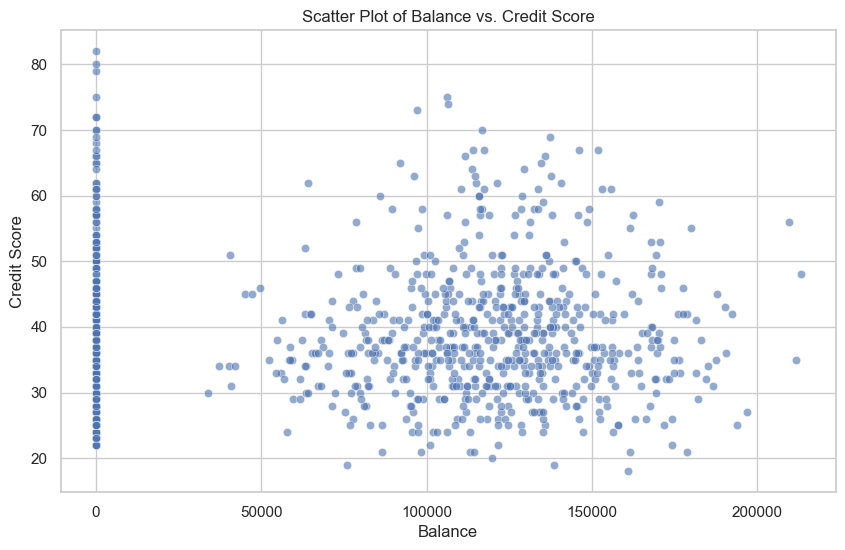

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='balance', y='age', alpha=0.6)

# Add titles and labels
plt.title('Scatter Plot of Balance vs. Credit Score')
plt.xlabel('Balance')
plt.ylabel('Credit Score')

# Show the plot
plt.show()

In [1]:
# Filter for active members
active_members = df[df['active_member'] == 1]

# Count churn and non-churn
churn_counts = active_members['churn'].value_counts()


NameError: name 'df' is not defined

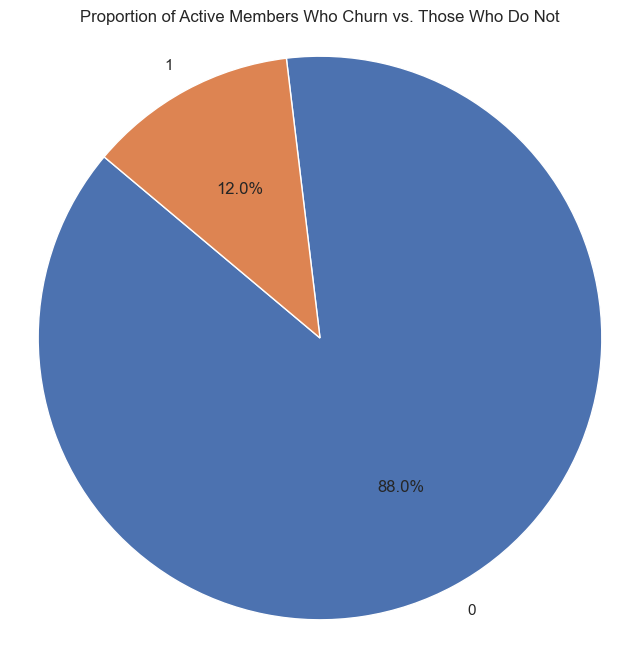

In [37]:
plt.figure(figsize=(8, 8))

# Create the pie chart
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=140)

# Add a title
plt.title('Proportion of Active Members Who Churn vs. Those Who Do Not')

# Show the plot
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

By analyzing the pie chart, stakeholders can make informed decisions about customer retention strategies and overall service improvement.
Only 12% of members are active churns and 88% are non active chruns

C:\Users\HANISHA C\AppData\Local\Temp\ipykernel_14736\2720010770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='credit_score', y='country', data=data, inner='quartile',palette="pastel")


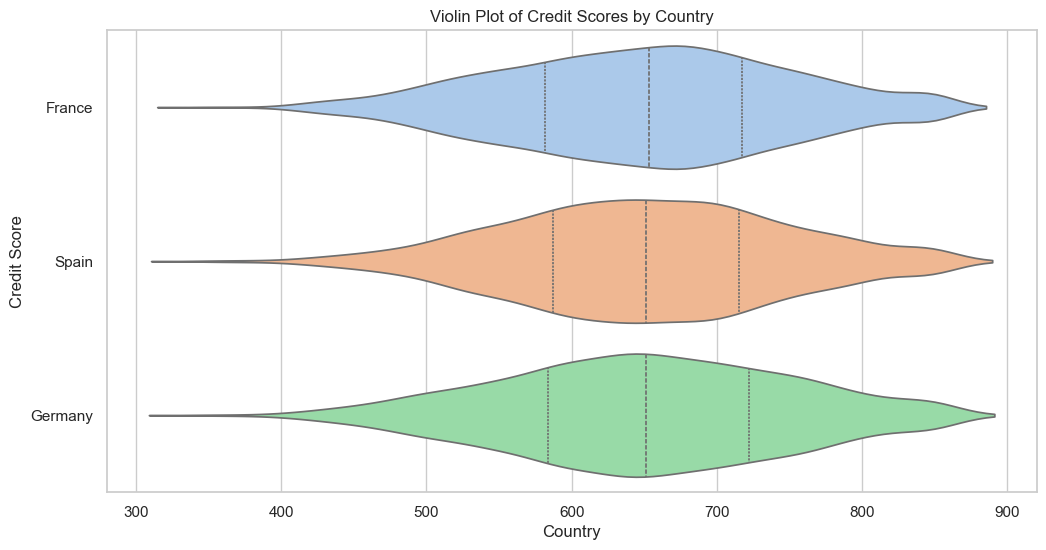

In [134]:
# Set the style for the plot
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='credit_score', y='country', data=data, inner='quartile',palette="pastel")

# Add titles and labels
plt.title('Violin Plot of Credit Scores by Country')
plt.xlabel('Country')
plt.ylabel('Credit Score')

# Show the plot
plt.show()

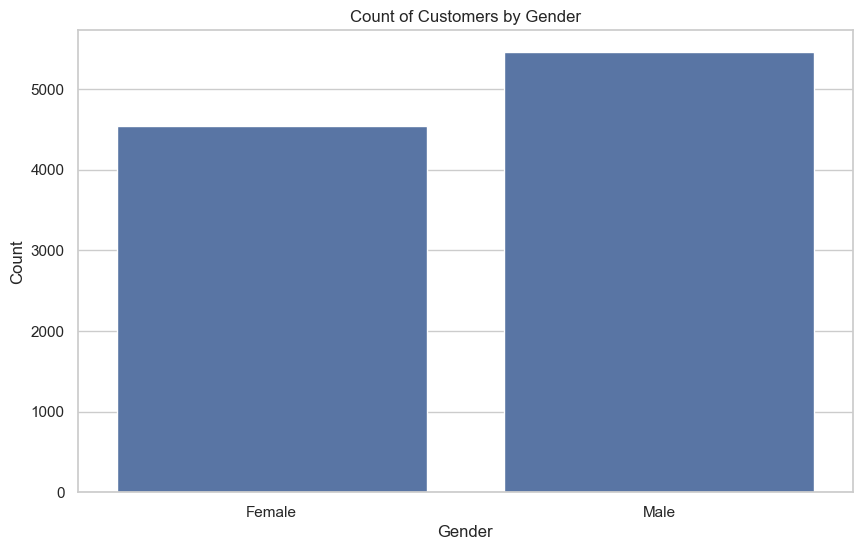

In [41]:
# Set the style for the plot
sns.set(style="whitegrid")

# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=data)

# Add titles and labels
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Show the plot
plt.show()

In [136]:
By seeing the count plot we can infer that, There are more male Customers than female customers in the bank.

SyntaxError: invalid syntax (2247725225.py, line 1)

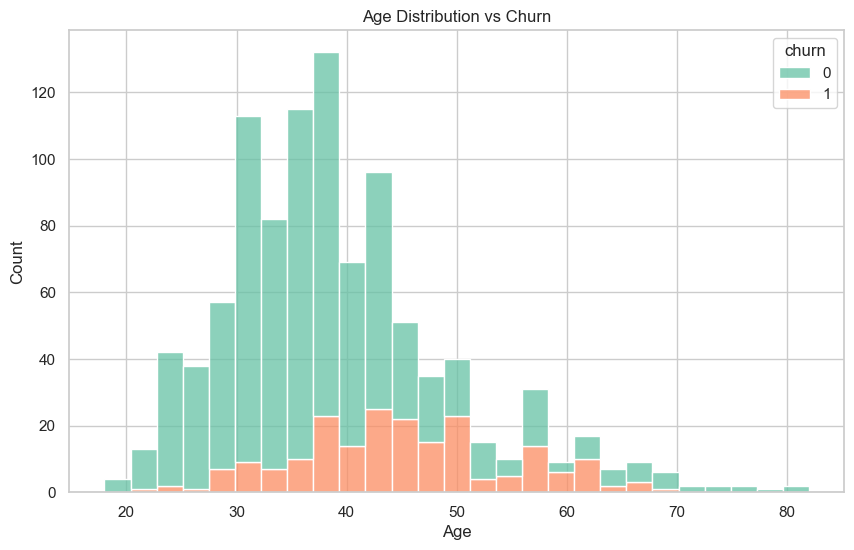

In [43]:
# Visualization 1: Distribution of churn by age
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age", hue="churn", multiple="stack", palette="Set2")
plt.title("Age Distribution vs Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Age Distribution vs Churn: Older customers seem to have a slightly higher likelihood of churn.

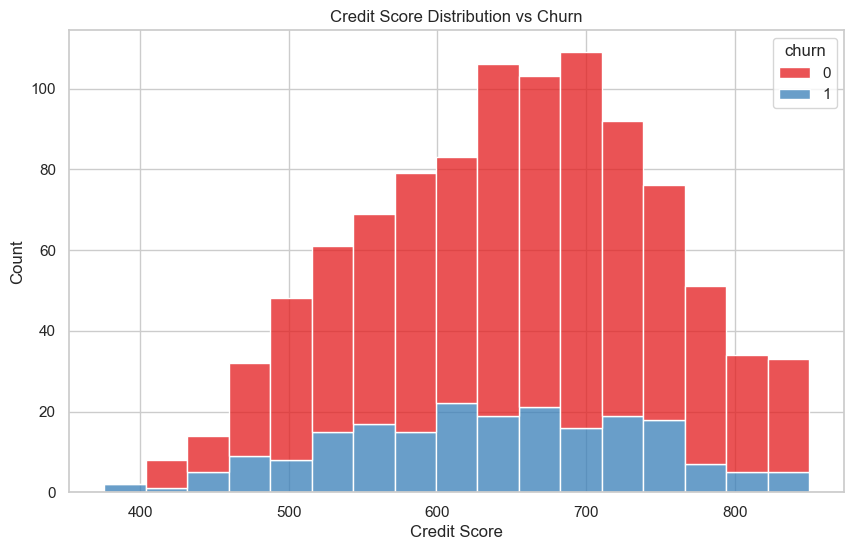

In [45]:
# Visualization 2: Churn rate by credit score
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="credit_score", hue="churn", multiple="stack", palette="Set1")
plt.title("Credit Score Distribution vs Churn")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

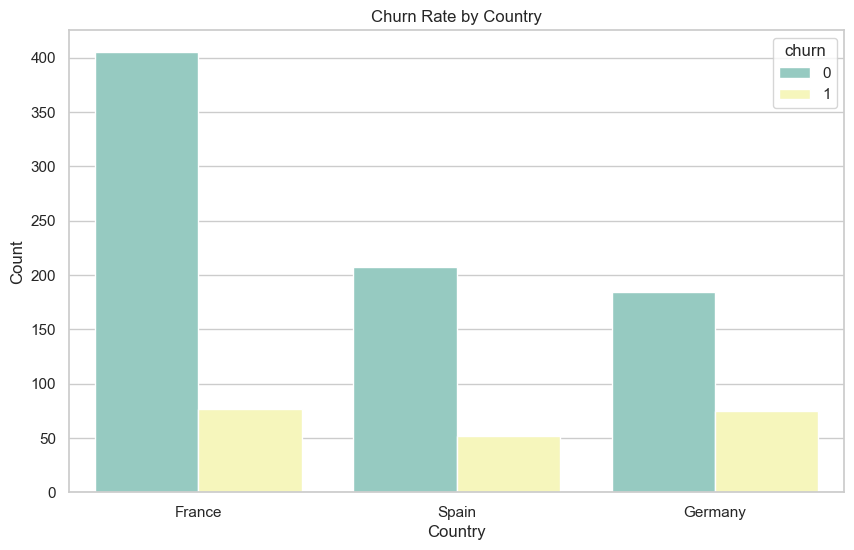

In [47]:
# Visualization 3: Churn rate by country
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="country", hue="churn", palette="Set3")
plt.title("Churn Rate by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

Churn Rate by Country: Churn rates vary by country, with France having a higher churn rate compared to Spain and Germany.

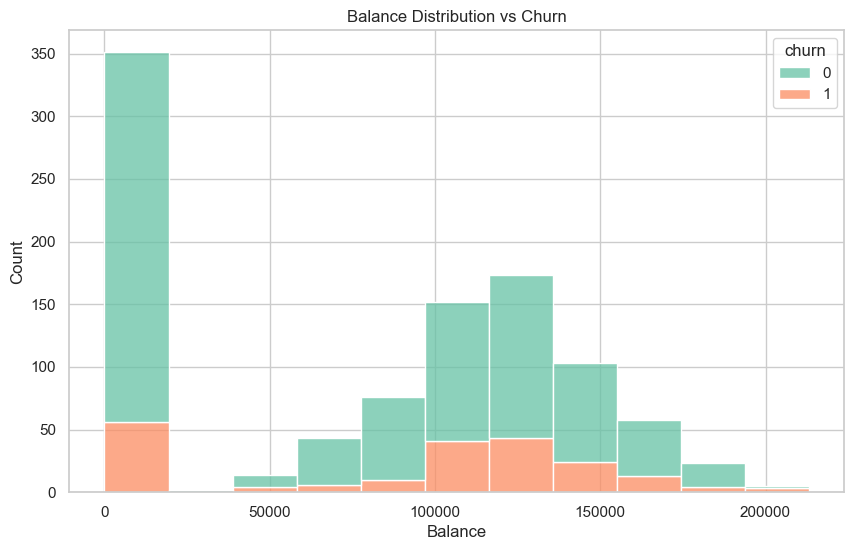

In [49]:
# Visualization 4: Churn rate by balance
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="balance", hue="churn", multiple="stack", palette="Set2")
plt.title("Balance Distribution vs Churn")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.show()

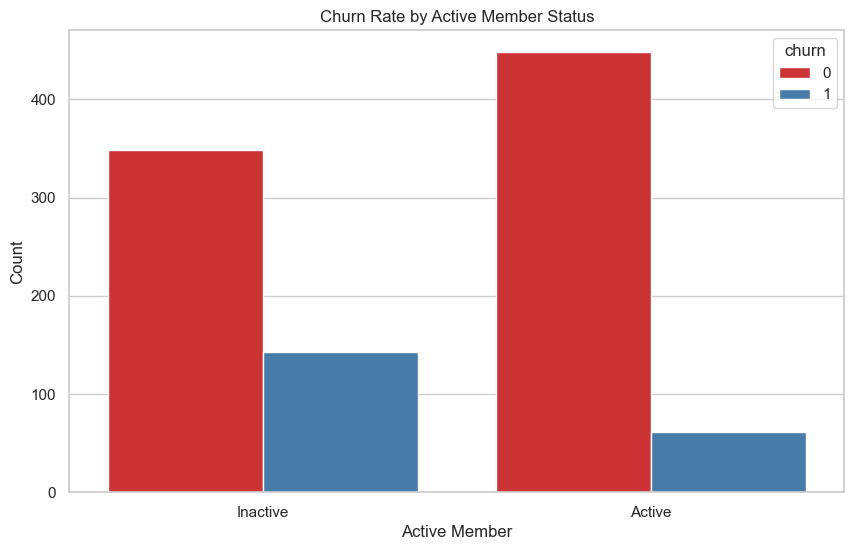

In [51]:
# Visualization 5: Churn rate by active member status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="active_member", hue="churn", palette="Set1")
plt.title("Churn Rate by Active Member Status")
plt.xlabel("Active Member")
plt.ylabel("Count")
plt.xticks([0, 1], ["Inactive", "Active"])
plt.show()

In [55]:
import pandas as pd
import sqlite3

# Load the dataset
file_path = 'Bank Customer Churn Prediction.csv'  # Update this to your file path
df = pd.read_csv(file_path)

# Connect to SQLite database (or create it if it doesn't exist)
conn = sqlite3.connect('customer_churn.db')  # Creates a new database file if it doesn't exist

# Push the data into the database
df.to_sql('churn_data', conn, if_exists='replace', index=False)

# Commit and close the connection
conn.commit()
conn.close()

print("Data successfully inserted into the SQLite database.")

Data successfully inserted into the SQLite database.


In [59]:
"C:\\Users\\HANISHA C\\Pictures\\Screenshots\\Screenshot 2024-10-26 140005.png"

'C:\\Users\\HANISHA C\\Pictures\\Screenshots\\Screenshot 2024-10-26 140005.png'

In [110]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Prepare features and target variable
X = df.drop(columns=['customer_id', 'churn', 'country', 'gender'])  # Drop irrelevant columns
y = df['churn']  # Target variable

# Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [112]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [94]:
X_train

array([[-0.32622142, -0.66001848, -0.35020386, ...,  0.64609167,
         0.97024255,  1.26421844],
       [-0.0778988 , -0.4693113 ,  0.68712986, ..., -1.54776799,
         0.97024255,  1.53793314],
       [-0.92633441, -0.56466489,  0.34135195, ..., -1.54776799,
        -1.03067011,  1.27965918],
       ...,
       [ 0.87400456, -0.08789694, -1.38753759, ..., -1.54776799,
        -1.03067011, -0.13685352],
       [ 0.17042381,  0.38887101,  1.03290776, ...,  0.64609167,
        -1.03067011, -0.04490188],
       [ 0.48082708,  1.15169974, -1.38753759, ...,  0.64609167,
         0.97024255, -0.80874677]])

In [96]:
X_test

array([[-0.56419726, -0.66001848, -0.69598177, ..., -1.54776799,
        -1.03067011, -1.01381126],
       [-0.28483432,  0.38887101, -1.38753759, ...,  0.64609167,
         0.97024255,  0.8049205 ],
       [-0.51246338,  0.4842246 , -0.35020386, ...,  0.64609167,
        -1.03067011, -0.72214659],
       ...,
       [-0.42968918, -0.66001848,  0.68712986, ...,  0.64609167,
         0.97024255,  0.90135294],
       [-0.72974567, -0.75537207, -1.04175968, ..., -1.54776799,
         0.97024255, -0.62732559],
       [-1.21604413, -1.61355439,  1.72446358, ..., -1.54776799,
        -1.03067011, -0.97792593]])

In [98]:
y_train

9069    1
2603    0
7738    0
1579    0
5058    0
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: churn, Length: 7000, dtype: int64

In [100]:
y_test

6252    0
4684    0
1731    0
4742    0
4521    0
       ..
8014    0
1074    0
3063    0
6487    0
4705    0
Name: churn, Length: 3000, dtype: int64

In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Prepare features and target variable
X = df.drop(columns=['customer_id', 'churn', 'country', 'gender'])  # Drop irrelevant columns
y = df['churn']  # Target variable

# Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

# Train and evaluate models
model_accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Convert predictions to binary for Linear Regression
    if name == "Linear Regression":
        predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    model_accuracies[name] = accuracy

# Print the model accuracies
print(model_accuracies)


{'Linear Regression': 0.8033333333333333, 'Logistic Regression': 0.8113333333333334, 'SVM': 0.8583333333333333, 'Random Forest': 0.8616666666666667, 'Decision Tree': 0.7746666666666666}


Support Vector model has more accuracy.

In [1]:
# Function to predict churn given new customer data
def predict_churn(customer_data):
    # Scale the input data using the same scaler
    customer_data_scaled = scaler.transform([customer_data])

    # Predict churn using all models
    predictions = {}

    for name, model in models.items():
        prediction = model.predict(customer_data_scaled)

        # For Linear Regression, convert predictions to binary
        if name == "Linear Regression":
            prediction = (prediction > 0.5).astype(int)

        predictions[name] = "Churn" if prediction[0] == 1 else "No Churn"

    # Display the predictions from each model
    for model_name, churn_status in predictions.items():
        print(f"{model_name} Prediction: {churn_status}")

# Example input for a new customer
# Input format: [credit_score, age, tenure, balance, products_number, credit_card, active_member, estimated_salary]
new_customer = [600, 20, 5, 50000.00, 2, 1, 1, 70000.00]

# Call the function to predict churn for the new customer
predict_churn(new_customer)


NameError: name 'scaler' is not defined